In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/RFMiD_Testing_Labels.csv
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/173.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/491.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/379.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/248.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/94.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/480.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/236.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/340.png
/kaggle/input/datasets/andrewmvd/retinal-disease-classification/Test_Set/Test_Set/Test/48.png
/kaggle/input/datasets/andrewmvd/retinal

**Classify fundus images into 46 different retinal diseases**

## Step 1: Important Library

In [7]:
# Step 1: Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from sklearn.metrics import classification_report, confusion_matrix

## Step 2: Data Setup and Augmentation

In [9]:
# Step 2: Data Setup and Augmentation
img_size = 224
batch_size = 32
data_dir = "/kaggle/input/datasets/andrewmvd/retinal-disease-classification"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2560 images belonging to 3 classes.
Found 640 images belonging to 3 classes.


## Step 3: Define Model (Custom CNN)

In [11]:
# Step 3: Define Model (Custom CNN)
# Custom CNN Model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(),
    BatchNormalization(),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(),
    BatchNormalization(),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(train_gen.class_indices), activation='softmax') 
])

## Step 4: Compile the Model

In [12]:
# Step 4: Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Step 5: Train the Model

In [13]:
# Step 5: Train the Model
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1777208744.996960     162 service.cc:152] XLA service 0x7d9af80115c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777208744.997018     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777208744.997025     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777208745.566139     162 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-26 13:05:48.263421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-26 13:05:48.413461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 2/80 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.3438 - loss: 19.7672 

I0000 00:00:1777208752.228171     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 472s 6s/step - accuracy: 0.5186 - loss: 9.6813 - val_accuracy: 0.1984 - val_loss: 1.3272
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 373s 5s/step - accuracy: 0.6038 - loss: 1.1315 - val_accuracy: 0.5938 - val_loss: 1.0423
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 365s 5s/step - accuracy: 0.5938 - loss: 1.0788 - val_accuracy: 0.6000 - val_loss: 1.0169
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.6041 - loss: 1.0216 - val_accuracy: 0.6000 - val_loss: 0.9982
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 365s 5s/step - accuracy: 0.6010 - loss: 1.0062 - val_accuracy: 0.6000 - val_loss: 0.9839
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 362s 5s/step - accuracy: 0.6089 - loss: 0.9766 - val_accuracy: 0.6000 - val_loss: 0.9731
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 365s 5s/step - accuracy: 0.5844 - loss: 0.9875 - val_accuracy: 0.6000 - val_loss: 0.9659
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 367s 5s/step - accuracy: 0.5867 - loss: 0.9891 - val_accuracy: 0.6000 - val_loss: 0.

## Step 6: Evaluate the Model and Generate Metrics

In [14]:
# Step 6: Evaluate the Model and Generate Metrics
val_gen.reset()
pred = model.predict(val_gen)
y_pred = np.argmax(pred, axis=1)
y_true = val_gen.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step


Classification Report:

                precision    recall  f1-score   support

Evaluation_Set       0.00      0.00      0.00       128
      Test_Set       0.00      0.00      0.00       128
  Training_Set       0.60      1.00      0.75       384

      accuracy                           0.60       640
     macro avg       0.20      0.33      0.25       640
  weighted avg       0.36      0.60      0.45       640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


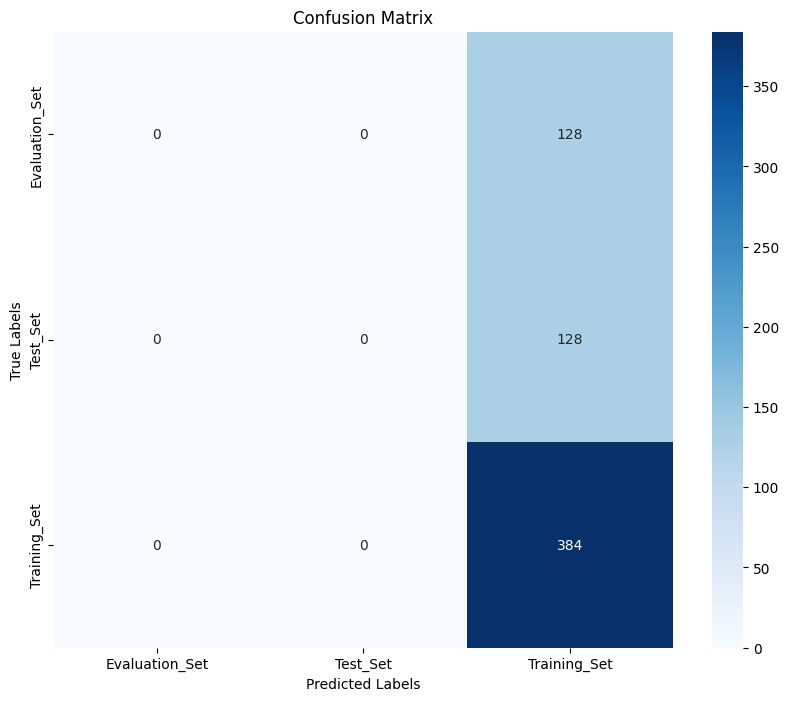

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Extract class labels from the generator to map indices back to class names
class_labels = list(val_gen.class_indices.keys())

# --- 1. Classification Report ---
print("Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)

# --- 2. Confusion Matrix ---
# Generate the raw confusion matrix array
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix using Seaborn's heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()